# GoalLab Stage 10: Train a structured citation policy with group rewards

Created by Shivam Bharadwaj · [Course home](../../../README.md) · [Stage map](../STAGES.md)

[Stage 09](09_small_model_sft_dpo.ipynb) · [Stage 11](11_tool_gateway_integration.ipynb)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/apply-theory/10_verifiable_reasoning_grpo.ipynb)

**Build:** a two-decision citation-and-extraction policy trained with group-relative rewards on GoalLab workspaces.

**Run:** use the full repository, install `requirements.txt` (Stage 09 also uses `requirements-modern.txt`), then restart the kernel and run all cells. Every stage reconstructs its inputs from shared GoalLab modules; earlier notebook execution is not required. The project progression is cumulative in capabilities, without hidden notebook state.

Code: MIT. Text and plots: CC BY 4.0. Results below are reproduced from the supplied GoalLab cases; the evaluation section explains their scope and failure cases.

**Learn the algorithm first:** [Course Notebook 10](../../../notebooks/10_verifiable_reasoning_grpo.ipynb). Then use this GoalLab stage to apply it to evidence gathering and briefing verification.


In [1]:
import sys, subprocess, platform, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'rl_course').is_dir()), Path.cwd())
if IN_COLAB and not (ROOT / 'rl_course').exists():
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(ROOT)], check=True)
if not (ROOT / 'rl_course' / 'goallab.py').exists():
    raise FileNotFoundError('Use the complete repository revision containing the GoalLab stages.')
sys.path.insert(0, str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course import goallab as goal
from rl_course import goallab_learning as learning
torch.set_num_threads(2)
%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#af824a', '#768165', '#87708c', '#f5f1e8'
plt.rcParams.update({'figure.figsize': (9, 4), 'figure.dpi': 110, 'figure.facecolor': PAPER,
    'axes.facecolor': PAPER, 'text.color': INK, 'axes.labelcolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]), 'axes.grid': True, 'grid.alpha': .15})
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' + '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(str(x).replace('|', '&#124;').replace('\n', '<br>') for x in row) + ' |' for row in rows)))
def learning_plot(runs):
    for label, run in runs.items():
        h = run['history']
        plt.plot(h[:, 0], h[:, 1], label=label)
    plt.xlabel('Training environment actions'); plt.ylabel('Exact policy return')
    plt.legend(); plt.tight_layout(); plt.show()
def report_policies(runs):
    table(['Controller', 'Exact return', 'Held-out briefing success', 'Calls/case'],
          [[label, round(run['env'].values(run['policy'])[0][run['env'].start_index], 3),
            f"{learning.heldout(run['policy'])['success']:.1%}", learning.heldout(run['policy'])['calls']]
           for label, run in runs.items()])
workspace = goal.make_workspace(7, 'test')
print(f'{goal.VERSION} | Python {platform.python_version()} | NumPy {np.__version__} | Torch {torch.__version__} | CPU')

GoalLab-v1 | Python 3.12.4 | NumPy 1.26.4 | Torch 2.11.0+cu130 | CPU


## Shared contract

One source is an approved measurement for the requested period. Other sources are drafts or forecasts, deliberately newer and numerically different. Training rows use 0..3; held-out rows use 4..7 and a different period. Authority rules stay the same. `search` reveals IDs and timestamps; `read` reveals content. A valid briefing needs the correct value, period, and citation.

The simulator and models are readable teaching code, not a security boundary. Final `verify()` is outside the policy interface. The first eight stages use a finite two-source abstraction: read twice, choose a citation, then submit or claim completion. Claiming completion produces no briefing. This fixed horizon makes exact comparisons possible; later stages vary investigation budgets.

## Learning objectives and the stage contract

Trace autoregressive citation choices; calculate group-relative credit; distinguish reward gradients from KL regularization.

**Input:** the shared evidence workspace or the preceding component reconstructed below. **Output:** the capability named in this stage, evaluated against the common briefing contract. Read the worked calculation before running the full experiment; then inspect the implementation and predict the constraint exercise.

## Work it out: reward is relative to the sampled group

For rewards `[0,0,1,1]`, centering and dividing by population standard deviation yields `[-1,-1,1,1]`. A group of identical rewards has no reward-driven preference signal. More optimization cannot recover information that was never present in the samples.

Citation is sampled first; extraction is conditioned on that citation. Treating the two decisions as independent would change the trajectory distribution and the learning problem.

In [2]:
reward=torch.tensor([0.,0.,1.,1.])
adv=(reward-reward.mean())/(reward.std(unbiased=False)+1e-8)
print('Group-relative advantages:',adv.tolist())
assert torch.allclose(adv,torch.tensor([-1.,-1.,1.,1.]))

Group-relative advantages: [-1.0, -1.0, 1.0, 1.0]


## Build the component

The central implementation is included here so you can step through and edit the update or tool logic. The shared modules retain the same reference implementation for the integrated project. Inspect shapes, terminal handling, frozen quantities, and the evaluator boundary before training.

In [3]:
from collections import deque
from copy import deepcopy
from torch import nn
from torch.distributions import Categorical
EvidenceMDP = goal.EvidenceMDP
greedy = learning.greedy
network = learning.network
from rl_course.goallab_preferences import evidence_features, evaluate_policy
make_workspace=goal.make_workspace
class CitationPolicy(nn.Module):
    """Autoregressive citation then extraction mode: exact row sum or +1 error."""
    def __init__(self):
        super().__init__()
        self.cite = nn.Linear(2, 2)
        self.extract = nn.Sequential(nn.Linear(4, 16), nn.Tanh(), nn.Linear(16, 2))

    def distributions(self, x, citation=None):
        first = Categorical(logits=self.cite(x))
        citation = first.sample() if citation is None else citation
        second = Categorical(logits=self.extract(torch.cat([x, nn.functional.one_hot(citation, 2).float()], 1)))
        return first, second, citation

    def sample(self, x):
        first, second, citation = self.distributions(x)
        offset = second.sample()
        return citation, offset, torch.stack([first.log_prob(citation), second.log_prob(offset)], 1)


def training_rewards(x, citation, offset, process=False):
    authority = x.gather(1, citation[:, None]).squeeze(1)
    exact = (offset == 0).float()
    # Outcome requires both. Process feedback adds an intermediate authority signal.
    return .5 * authority + .5 * authority * exact if process else authority * exact


def group_train(seed=7, updates=60, process=False):
    torch.manual_seed(seed)
    train = [make_workspace(i) for i in range(64)]
    test = [make_workspace(i, 'test') for i in range(64)]
    x = evidence_features(train)
    model = CitationPolicy()
    optimizer = torch.optim.Adam(model.parameters(), lr=.015)
    # A short SFT warm start; no assumption that all sampled groups contain a success.
    for _ in range(8):
        first, second, _ = model.distributions(x, x.argmax(1))
        loss = -(first.log_prob(x.argmax(1)) + second.log_prob(torch.zeros(len(x), dtype=torch.long))).mean()
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    reference = deepcopy(model).requires_grad_(False)
    before = evaluate_policy(model, test)
    optimizer = torch.optim.Adam(model.parameters(), lr=.01)
    history = []
    for u in range(updates):
        batch = x[torch.randint(len(x), (16,))].repeat_interleave(8, 0)
        with torch.no_grad():
            citation, offset, old_logp = model.sample(batch)
            rewards = training_rewards(batch, citation, offset, process).reshape(16, 8)
            advantage = ((rewards - rewards.mean(1, keepdim=True)) /
                         (rewards.std(1, keepdim=True, unbiased=False) + 1e-8)).flatten()
            rf, rs, _ = reference.distributions(batch, citation)
        for _ in range(3):
            first, second, _ = model.distributions(batch, citation)
            logp = torch.stack([first.log_prob(citation), second.log_prob(offset)], 1)
            ratio = (logp - old_logp).exp()
            objective = torch.minimum(ratio * advantage[:, None], ratio.clamp(.8, 1.2) * advantage[:, None]).mean()
            kl = (torch.distributions.kl_divergence(first, rf) + torch.distributions.kl_divergence(second, rs)).mean() / 2
            loss = -objective + .02 * kl
            optimizer.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1); optimizer.step()
        if (u + 1) % 10 == 0:
            history.append((u + 1, evaluate_policy(model, test),
                            float((rewards.std(1, unbiased=False) == 0).float().mean()), float(kl.detach())))
    return {'model': model, 'reference': reference, 'before': before, 'history': np.array(history)}

## 1. A structured reasoning trajectory

Both documents are already read. The first action chooses a citation; the second chooses exact extraction or a +1 perturbation and conditions on the sampled citation. This learned autoregressive policy is not a pretrained LLM. The row-sum tool performs arithmetic; the policy learns to select supported extraction.

After a short SFT warm start, sample groups of eight, normalize rewards inside each group, and optimize clipped probability ratios with an exact categorical KL at sampled prefix states. Zero-variance groups have zero normalized advantage. The final held-out evaluator is separate from training rewards.

| Training signal | After SFT | After group updates | Zero-variance groups at last update |
|---|---|---|---|
| Outcome | 0.5234375 | 0.96484375 | 0.875 |
| Process + outcome | 0.5234375 | 0.96484375 | 0.875 |

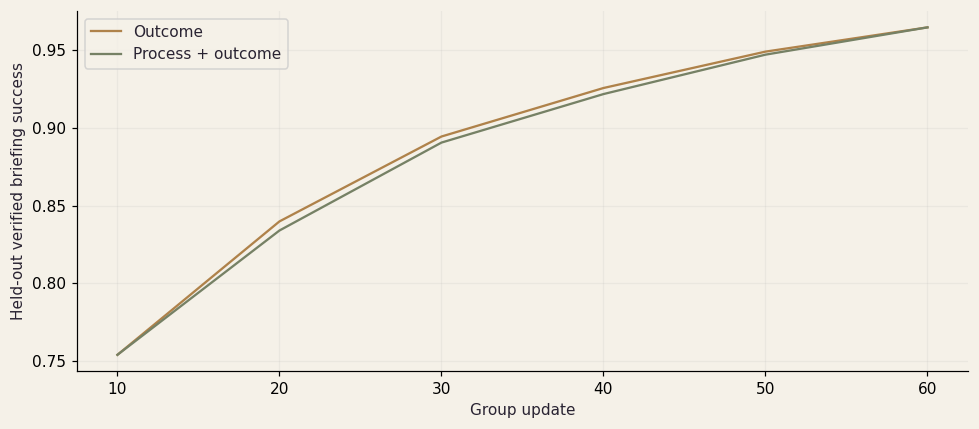

In [4]:
from rl_course import goallab_preferences as preferences
runs={label:group_train(7,60,process=process) for label,process in [('Outcome',False),('Process + outcome',True)]}
for label,r in runs.items():
    plt.plot(r['history'][:,0],r['history'][:,1],label=label)
table(['Training signal','After SFT','After group updates','Zero-variance groups at last update'],
      [[label,r['before'],r['history'][-1,1],r['history'][-1,2]] for label,r in runs.items()])
plt.xlabel('Group update'); plt.ylabel('Held-out verified briefing success'); plt.legend(); plt.tight_layout(); plt.show()

## 2. Inspect a generated artifact

Evaluate the final value and citation together. Correct extraction from a draft is still an invalid briefing.

In [5]:
model=runs['Process + outcome']['model']
with torch.no_grad():
    citation,offset,_=model.sample(preferences.evidence_features([workspace]))
source=workspace.sources[int(citation)]
briefing=goal.Briefing(source.value+int(offset),source.source_id,workspace.period)
print(briefing,goal.verify(workspace,briefing))

Briefing(value=11, citation='test-7-source-1', period='2026-02', abstained=False) {'success': True, 'supported': True, 'value_correct': True}


## Interpret the evidence

Outcome and mixed-process runs may reach similar final scores. Examine tied groups and the shared eligibility features before crediting the intermediate reward. A single seed is a demonstration, not an ablation conclusion.

## Change a constraint: predict first

Construct a group in which every completion has the same reward. What is its policy-gradient contribution after group normalization?

### Worked solution

Run this after writing your prediction. Compare the changed condition with the reference condition above.

In [6]:
rewards=torch.ones(8)
adv=(rewards-rewards.mean())/(rewards.std(unbiased=False)+1e-8)
print('Advantages:',adv.tolist()); assert torch.equal(adv,torch.zeros(8))
print('The reward-driven update vanishes for this group; a KL term can still act.')

Advantages: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
The reward-driven update vanishes for this group; a KL term can still act.


## What this stage contributes

A verifiable group-training stage for citation and extraction choices. Theory: [GRPO](../../../chapters/39-grpo-and-reinforcement-learning-for-reasoning/README.md).

[Stage 09](09_small_model_sft_dpo.ipynb) · [Stage 11](11_tool_gateway_integration.ipynb)